In [1]:
import numpy as np
import scipy.stats as stats
import ipywidgets as widgets
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks");
colors = sns.color_palette()

import pandas as pd

import urllib.request
import os
def download(
    url : str,
    local_filename : str = None
):
    """Download a file from a url.
    
    Arguments
    url            -- The url we want to download.
    local_filename -- The filemame to write on. If not
                      specified 
    """
    if local_filename is None:
        local_filename = os.path.basename(url)
    urllib.request.urlretrieve(url, local_filename)

url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E1_A.csv'
download(url)
E1_A = pd.read_csv('E1_A.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E1_e_yy.csv'
download(url)
E1_e_yy = pd.read_csv('E1_e_yy.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E1_Force.csv'
download(url)
E1_Force = pd.read_csv('E1_Force.csv', header=None)

# Repeat for E2
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E2_A.csv'
download(url)
E2_A = pd.read_csv('E2_A.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E2_e_yy.csv'
download(url)
E2_e_yy = pd.read_csv('E2_e_yy.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E2_Force.csv'
download(url)
E2_Force = pd.read_csv('E2_Force.csv', header=None)

# Repeat for E3
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E3_A.csv'
download(url)
E3_A = pd.read_csv('E3_A.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E3_e_yy.csv'
download(url)
E3_e_yy = pd.read_csv('E3_e_yy.csv', header=None)
url = 'https://github.com/ebilionis/core-me-data-science-activities-public/raw/refs/heads/main/data/stress-strain/E3_Force.csv'
download(url)
E3_Force = pd.read_csv('E3_Force.csv', header=None)

# Drop values for which strain is greater that 0.005
# build the mask on the original strain DataFrame
mask1 = E1_e_yy[0] < 0.005

# now subset both, using .loc so it respects the mask’s index
E1_e_yy  = E1_e_yy.loc[mask1].reset_index(drop=True)
E1_Force = E1_Force.loc[mask1].reset_index(drop=True)

mask2 = E2_e_yy[0] < 0.005
E2_e_yy  = E2_e_yy.loc[mask2].reset_index(drop=True)
E2_Force = E2_Force.loc[mask2].reset_index(drop=True)

mask3 = E3_e_yy[0] < 0.005
E3_e_yy  = E3_e_yy.loc[mask3].reset_index(drop=True)
E3_Force = E3_Force.loc[mask3].reset_index(drop=True)

# ME 323: Activity 1 - Introduction to Bayesian Inference

## References:
+ The dataset for this activity was kindly provided by Dr. Akshay J. Thomas, as referenced in this [paper](https://www.sciencedirect.com/science/article/pii/S0266353822003724).
+ Concepts were adapted from Professor Bilionis's [ME 239 course](https://purduemechanicalengineering.github.io/me-239-intro-to-data-science/lecture13/fitting-the-normal-with-maximum-likelihood.html) and his [ME 539 course](https://predictivesciencelab.github.io/data-analytics-se/lecture12/intro.html)

## Instructions:

+ **How to run this activity on Google Colab:** Just click [here](https://colab.research.google.com/github/ebilionis/core-me-data-science-activities-public/blob/master/me274/activity_01.ipynb) if you are not already there.
+ **How to turn this activity in:** Please submit the activity as a regular homework assignment.
+ **How to turn the activity to a PDF file:** When you open it on Google Colab, and you are done with your work, just do: File->Print->Save as PDF. Some figures may be misaligned. That's fine.
+ **Save your version of the activity on your Google Drive:**
Google Colab will delete your work once you close the browser. To save a copy to your Google Drive, do:
File->Save a copy in Drive
+ **Typing math:** You can use LaTeX to format your math. Double click on any math cell to see the raw LaTeX code. Google Colab can help you do this using generative AI.

## Engineering Objective:

The experimental data consist of tensile stress–strain measurements obtained from short fiber‐reinforced polymer composite specimens. In these tests, specimens are subjected to controlled tensile loads, and the resulting strain is recorded; however, the measurements naturally include noise from both the experimental process (e.g., measurement uncertainty, systematic bias due to setup or clamping) and inherent material variability (e.g., fiber orientation differences across the specimen). The aim of the exercise is to use Bayesian inference techniques to estimate the modulus of elasticity from this noisy data. In this task, students will assume that in the elastic regime, the relationship between stress $\sigma$ and strain $\epsilon$ can be approximated by a linear model where the predicted stress is given by 

$$
\sigma = E \epsilon
$$

with $E$ representing the modulus of elasticity.

## **Part 0: Inspect the Data**

I am going to load the data for you as it is a bit tedious. If you do not see it, be sure to go back and run the first cell. Because we are working with real data, it is important to clean your data. Dr. Thomas has given us CSV files with the data  points of an experiment as the rows and repeated the experiment on different samples as the columns. Each sample does not necessarily have the same number of data points. 

The shape of E1_strain is (117, 12)
The shape of E1_force is (117, 12)


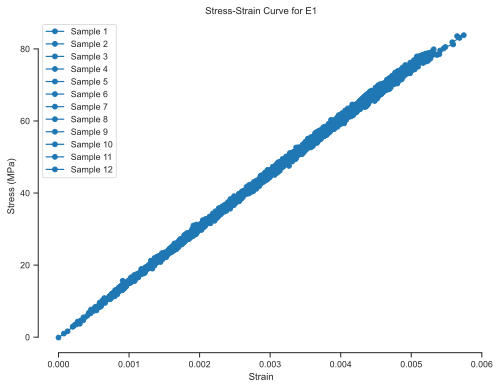

In [2]:
# Drop the NaN values from the dataframes
E1_A = E1_A.dropna()
E1_e_yy = E1_e_yy.dropna()
E1_Force = E1_Force.dropna()

# Convert to numpy arrays for easier manipulation
E1_area = np.array(E1_A) # mm^2
E1_strain = np.array(E1_e_yy) # mm/mm
E1_force = np.array(E1_Force) # N

print(f'The shape of E1_strain is {E1_strain.shape}')
print(f'The shape of E1_force is {E1_force.shape}')

# Convert to MPa
E1_stress = E1_force / E1_area.T

# Plotting
plt.figure(figsize=(8, 6))
# Plot each sample with the label of the sample
for i in range(E1_stress.shape[1]):
    plt.plot(E1_strain[:, i], E1_stress[:, i], 'o-', label=f'Sample {i+1}', color=colors[0])
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Stress-Strain Curve for E1')
plt.legend()
sns.despine(trim=True)
plt.show()

Because we are dealing with additively manufactured materials, we have interesting anisotropic properties. Above we looked at the stress-strain curve in the printing direction, this is referred to as E1. Let's repeat what we did above for the transversal direction, E2, and the stacking direction, E3.

In [3]:
# Repeat for E2
# Drop the NaN values from the dataframes
E2_A = E2_A.dropna()
E2_e_yy = E2_e_yy.dropna()
E2_Force = E2_Force.dropna()
# Convert to numpy arrays for easier manipulation
E2_area = np.array(E2_A) # mm^2
E2_strain = np.array(E2_e_yy) # mm/mm
E2_force = np.array(E2_Force) # N
# Convert to MPa
E2_stress = E2_force / E2_area.T
# Repeat for E3
# Drop the NaN values from the dataframes
E3_A = E3_A.dropna()
E3_e_yy = E3_e_yy.dropna()
E3_Force = E3_Force.dropna()
# Convert to numpy arrays for easier manipulation
E3_area = np.array(E3_A) # mm^2
E3_strain = np.array(E3_e_yy) # mm/mm
E3_force = np.array(E3_Force) # N

# Convert to MPa
E3_stress = E3_force / E3_area.T

Let's plot all three directions together.

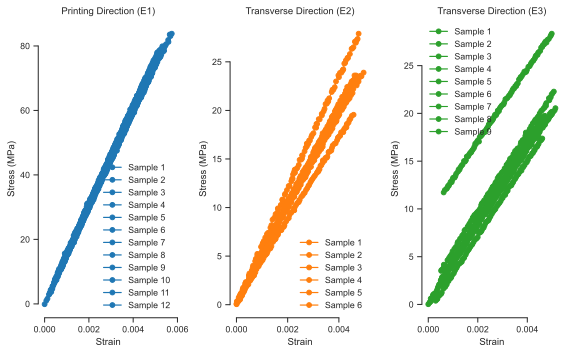

In [4]:
# Plot all three on subplots with data points 'o'
fig, axs = plt.subplots(1, 3, figsize=(8, 5))
for i in range(E1_stress.shape[1]):
    axs[0].plot(E1_strain[:, i], E1_stress[:, i], 'o-', label=f'Sample {i+1}', color=colors[0])
axs[0].set_title('Printing Direction (E1)')
axs[0].set_xlabel('Strain')
axs[0].set_ylabel('Stress (MPa)')
axs[0].legend(frameon=False)

for i in range(E2_stress.shape[1]):
    axs[1].plot(E2_strain[:, i], E2_stress[:, i], 'o-', label=f'Sample {i+1}', color=colors[1])
axs[1].set_title('Transverse Direction (E2)')
axs[1].set_xlabel('Strain')
axs[1].set_ylabel('Stress (MPa)')
axs[1].legend(frameon=False, loc='lower right')

for i in range(E3_stress.shape[1]):
    axs[2].plot(E3_strain[:, i], E3_stress[:, i], 'o-', label=f'Sample {i+1}', color=colors[2])
axs[2].set_title('Transverse Direction (E3)')
axs[2].set_xlabel('Strain')
axs[2].set_ylabel('Stress (MPa)')
axs[2].legend(frameon=False)

sns.despine(trim=True)
plt.tight_layout()
plt.show()

#### **The Statistical Challenge**

**What we observe:** Each direction shows different stress-strain relationships with noisy, scattered data points. Even within the same direction (particularly in the transverse direction), different specimens give slightly different slopes.

**The engineering question:** What is the Young's modulus E for each direction?

**The statistical challenge:** How do we extract reliable estimates of E from this noisy data? How do we quantify our uncertainty?

**Two philosophical approaches:**

1. **Frequentist approach** (Parts 1-3): 
   - "E has one true value, let's find our best estimate"
   - Tools: Maximum likelihood estimation
   
2. **Bayesian approach** (Parts 4-5):
   - "E is uncertain, let's quantify our beliefs about it"  
   - Tools: Prior and posterior distributions


**Our Strategy:** We will use probabilistic modeling to extract reliable estimates from this noisy data—printing, transverse, and stacking. It is evident that each direction yields a different elastic modulus, reflecting the anisotropic nature of the composite material. In particular, the transverse direction (E2) exhibits appreciable scatter: individual measurements differ from one sample to the next. This variability makes it clear that a single, deterministic value cannot capture the uncertainty inherent in the material’s response.

Instead, we treat the stress as a random variable described by a probability distribution. Our goal—the inference task—is to use the noisy, scattered observations to estimate that distribution: to identify not only the most likely modulus of elasticity but also how confident we are in that estimate. Probabilistic modeling provides a principled framework for doing just that, by linking observed data to unknown parameters through a likelihood function and, in some cases, a prior belief.

## **Part 1: Introduce a likelihood function**

**The Big Picture:** We have noisy stress-strain data and want to estimate Young's modulus E. But there are **two fundamentally different philosophical approaches** we could take:

1. **Frequentist/MLE approach** (Parts 2-3): Treat E as an unknown fixed value to estimate
2. **Bayesian approach** (Parts 4-5): Treat E as a random variable with a probability distribution

**The likelihood function is the common foundation** for both approaches - it quantifies how probable our observed data is for different values of E.

**Tutorial:**

The likelihood function is a mathematical representation of how likely the observed data is, given a set of parameters. Let's take a look at the general form of the likelihood function:


**General formulation:**  
We model each observation $\hat y_i$ as the true model output plus additive noise:

$$
\hat y_i = f(x_i; \theta) + \eta_i,
$$

where
- $x_i$ is the input,  
- $\theta$ is the vector of parameters,  
- $f(x_i; \theta)$ is the deterministic model, and  
- $\eta_i$ is measurement noise.

As a probability distribution, we write

$$
p(\hat y_i \mid x_i, \theta)
$$

which mean the probability of observing $\hat y_i$ given the single input $x_i$ and the parameters $\theta$.  

Since we have multiple observations, we can write the likelihood function as a product of the individual likelihoods:

$$
L(\theta) = \prod_{i=1}^N p(\hat y_i \mid x_i, \theta) = \prod_{i=1}^N p(f(x_i; \theta) + \eta_i \mid x_i, \theta).
$$


**Specific case:**  
- Input: $x_i = \epsilon_i$ (strain)  
- Observation: $\hat y_i$ (stress)  I am going to use $\hat y$ instead of $\sigma$ to avoid confusion with noise of the Gaussian distribution.
- Parameters: $\theta = E$ (elastic modulus)  
- Model:

$$
f(x_i; \theta) = E\,\epsilon_i.
$$

Thus

$$
\hat y_i = E\,\epsilon_i + \eta_i.
$$


**Gaussian noise assumption:**  

We now need to make a choice about how we think the noise behaves. A common choice is the normal distribution because noise from many sources tend to be normally distributed by the [central limit theorem](https://en.wikipedia.org/wiki/Central_limit_theorem). 

**Why this matters for engineering:** Material testing involves multiple sources of noise - measurement uncertainty, specimen variability, test setup variations, etc. The central limit theorem suggests their combined effect will be approximately Gaussian.

$$
\eta_i \sim \mathcal{N}(0,\sigma^2)
$$

According to our model formulation, now our observed data $\hat y_i$ also follows a Gaussian distribution, centered at $E\,\epsilon_i$ with variance $\sigma^2$. We can write this as:

$$
\hat y_i \sim \mathcal{N}(E\,\epsilon_i, \sigma^2).
$$

Let's write this down as a probability density function (PDF) for a single observation:

$$
p(\hat y_i \mid \epsilon_i, E, \sigma^2)
= \frac{1}{\sqrt{2\pi\,\sigma^2}}
  \exp\Bigl[
    -\frac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}
  \Bigr].
$$

We can now write the likelihood function as a product of the individual observations:

$$
L(E,\sigma^2)
= \prod_{i=1}^N
  \frac{1}{\sqrt{2\pi\,\sigma^2}}
  \exp\Bigl[
    -\frac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}
  \Bigr].
$$

**Key insight:** This likelihood function $L(E,\sigma^2)$ tells us "for any given values of E and σ², how likely is it that we would observe our specific stress-strain data?"

**Looking ahead:** 
- In **Parts 2-3 (MLE)**, we'll find the single values of E and σ² that maximize this likelihood
- In **Parts 4-5 (Bayesian)**, we'll use this same likelihood but combine it with prior beliefs to get a full probability distribution for E



#### Alternative noise distribution

**Question:**

Real tensile tests can exhibit occasional outliers or heavier‑tailed errors due to slippage, gauge calibration issues, or material inhomogeneities. 
The Gaussian distribution is a good choice for many applications, but it may not be the best choice for all data. In particular, the Gaussian distribution has thin tails, which means that it does not handle outliers well (consider the big outlier sample in the stacking direction). Pick a distribution that you think would model the noise well and derive the likelihood function for it. (Hint: Start by writing down the PDF of the distribution)

*YOUR ANSWER HERE!*

Example Solutions:

**Solution a - Student-t noise:**  
Assume $\eta_i \sim t_{\nu}(0,\sigma^2)$ (Student-t with $\nu$ degrees of freedom and scale $\sigma$). Then each individual density is

$$
p(\hat y_i \mid \epsilon_i, E, \sigma^2, \nu)
= \frac{\Gamma\bigl(\tfrac{\nu+1}{2}\bigr)}{\Gamma\bigl(\tfrac{\nu}{2}\bigr)\sqrt{\nu\pi\sigma^2}}
\Bigl[1 + \frac{(\hat y_i - E\,\epsilon_i)^2}{\nu\sigma^2}\Bigr]^{-\tfrac{\nu+1}{2}}.
$$

Since $\hat y_i = E\,\epsilon_i + \eta_i$, the full joint likelihood over $N$ observations is

$$
L(E,\sigma^2,\nu;\hat y_i,\epsilon_i)
= \prod_{i=1}^{N}
  \frac{\Gamma\!\bigl(\tfrac{\nu+1}{2}\bigr)}{\Gamma\!\bigl(\tfrac{\nu}{2}\bigr)\sqrt{\nu\pi\,\sigma^2}}
  \Bigl[1 + \frac{(\hat y_i - E\,\epsilon_i)^2}{\nu\,\sigma^2}\Bigr]^{-\tfrac{\nu+1}{2}}.
$$

**Solution b - Laplace noise:**  
Assume $\eta_i \sim \mathrm{Laplace}(0,b)$ with scale $b$. Then each individual density is

$$
p(\hat y_i \mid \epsilon_i, E, b)
= \frac{1}{2b}
  \exp\Bigl(-\frac{|\hat y_i - E\,\epsilon_i|}{b}\Bigr).
$$

The full likelihood over $N$ observations is

$$
L(E,b; \hat y, \epsilon)
= \prod_{i=1}^N
  \frac{1}{2b}
  \exp\Bigl(-\frac{|\hat y_i - E\,\epsilon_i|}{b}\Bigr).
$$



## **Part 2: Maximum Likelihood Estimation**

**The Frequentist Philosophy:** 

Maximum Likelihood Estimation (MLE) embodies a particular way of thinking about unknown parameters:

**Core assumption:** E and σ² are **fixed, unknown constants** that exist in nature. Our job is to find the single "best guess" values that make our observed data most probable.

**The MLE Strategy:**
1. **Setup**: We have a likelihood function L(E,σ²) from Part 1
2. **Goal**: Find the specific values E_mle and σ²_mle that maximize this likelihood  
3. **Interpretation**: These are our "best estimates" - we'll treat them as the true values
4. **Uncertainty**: Comes only from measurement noise, not uncertainty about the parameter values themselves

**Tutorial:**

Now that we have a likelihood function, we can use it to fit the model to the data. For our problem we will be finding a **single point estimate** of the elastic modulus and then plugging this into our noise model to get stress predictions.

**This contrasts with the Bayesian approach** (Parts 4-5) where we'll treat E as having a probability distribution rather than being a single fixed value.

**General formulation:**

$$
\max_{\theta} p(\hat y \mid x, \theta) = \prod_{i=1}^N p(\hat y_i \mid x_i, \theta).
$$

In practice we want to maximize the logarithm of the likelihood function, which is called the log-likelihood function. The log-likelihood function is numerically easier to work with because it turns products into sums:

$$
\max_{\theta} \log p(\hat y \mid x, \theta) = \sum_{i=1}^N \log p(\hat y_i \mid x_i, \theta).
$$

**Specific case:**

Lets call the log-likelihood function $J(E, \sigma^2)$. For our case with the normal distribution, we have:

$$
J(E, \sigma^2) = \sum_{i=1}^N
  \log\Bigl[
    \frac{1}{\sqrt{2\pi\,\sigma^2}}
    \exp\Bigl[
      -\frac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}
    \Bigr]
  \Bigr].
$$

To find the best parameters, we need to maximize the log-likelihood function with respect to our model parameters. In practice, we typically minimize the negative log-likelihood function, which is equivalent to maximizing the log-likelihood function. So we want to find

$$
\min_{E, \sigma^2} -J(E, \sigma^2).
$$

In our case we can actually do this analytically by setting the derivative of the log-likelihood function to zero with respect to each parameter that we want to find.
We can then solve for the parameters.

$$
\frac{\partial J}{\partial E} = \frac{\partial}{\partial E} \sum_{i=1}^N
  \log\Bigl[
    \frac{1}{\sqrt{2\pi\,\sigma^2}}
    \exp\Bigl[
      -\frac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}
    \Bigr]
  \Bigr]
$$

Breaking down with logarithm properties we have

$$
\frac{\partial J}{\partial E} = \sum_{i=1}^N
  \frac{\partial}{\partial E}
  \Bigl[
    -\frac{1}{2}\log(2\pi) - \frac{1}{2}\log(\sigma^2) - \frac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}
  \Bigr]
$$

Drop the terms that are constant wrt to E. Then take the summation inside

$$
\frac{\partial J}{\partial E} = -\frac{1}{2\sigma^2}\sum_{i=1}^N
  \frac{\partial}{\partial E}
  \Bigl[
    (\hat y_i - E\,\epsilon_i)^2
  \Bigr]
$$

Using the chain rule we have

$$
\frac{\partial J}{\partial E} = -\frac{1}{2\sigma^2}\sum_{i=1}^N
  \Bigl[
    2(\hat y_i - E\,\epsilon_i)(-\epsilon_i)
  \Bigr]
$$

We set equal to zero and simplifying we have

$$
\frac{\partial J}{\partial E} = \frac{1}{\sigma^2}\sum_{i=1}^N
  (\hat y_i - E\,\epsilon_i)\epsilon_i
$$

Solving for E we get

$$
E = \frac{\sum_{i=1}^N \hat y_i \epsilon_i}{\sum_{i=1}^N \epsilon_i^2}
$$

**Question:**

Do the same for $\sigma^2$.


*YOUR ANSWER HERE!*

**Solution:**

**Goal**: Find the values of E and σ² that maximize the likelihood (make our observed data most probable).

**Strategy**: Take derivatives of the log-likelihood and set them to zero.

For the log-likelihood:
$$
J(E,\sigma^2)
= \sum_{i=1}^N
  \log\Bigl[
    \tfrac{1}{\sqrt{2\pi\,\sigma^2}}
    \exp\!\bigl(-\tfrac{(\hat y_i - E\,\epsilon_i)^2}{2\,\sigma^2}\bigr)
  \Bigr].
$$

Dropping terms constant in $\sigma^2$ gives  
$$
J(E,\sigma^2)
= -\frac{N}{2}\log(\sigma^2)
  - \frac{1}{2\,\sigma^2}
    \sum_{i=1}^N (\hat y_i - E\,\epsilon_i)^2
  + \text{const}.
$$

**Finding the optimal σ²:**
Differentiate with respect to $\sigma^2$:  
$$
\frac{\partial J}{\partial \sigma^2}
= -\frac{N}{2\,\sigma^2}
  + \frac{1}{2\,(\sigma^2)^2}
    \sum_{i=1}^N (\hat y_i - E\,\epsilon_i)^2.
$$

Setting $\frac{\partial J}{\partial \sigma^2}=0$ yields  
$$
\sigma^2_{\text{MLE}}
= \frac{1}{N}
  \sum_{i=1}^N (\hat y_i - E\,\epsilon_i)^2.
$$

**Key insight**: The MLE for σ² is just the average squared residual - how much our linear model misses the data on average.


#### **Conceptual Checkpoint: What We've Accomplished**

**Parts 1-2 Summary:**
- **Built a likelihood function** that connects our stress-strain model to observed data
- **Derived the MLE formulas** for finding optimal E and σ² values
- **Established the frequentist mindset**: Parameters are fixed unknowns to be estimated

**What's Coming Next:**
- **Part 3**: Apply these MLE formulas to real data → get point estimates + prediction bands  
- **Parts 4-5**: Shift to Bayesian thinking → get probability distributions + credible intervals

**Key Realization:** The same likelihood function from Part 1 will be used in both approaches, but interpreted differently:
- **MLE**: "Find the parameter values that maximize this likelihood"  
- **Bayesian**: "Use this likelihood to update our beliefs about parameter distributions"

**For engineering students:** Both approaches have their place - MLE for quick point estimates, Bayesian for comprehensive uncertainty quantification!


## **Part 3: Find the modulus of elasticity with MLE**

**Key Concept:** In the Maximum Likelihood Estimation (MLE) approach, we assume that Young's modulus E is a *single fixed value* that we want to estimate. We don't put a probability distribution on E itself - instead, we find the "best guess" point estimate.

**What we're doing:**
- Find the single value of E that makes our observed data most likely
- Treat this E as the "true" value for making predictions
- Account for uncertainty only in the form of measurement noise around our predictions

**This is different from the Bayesian approach** (Part 5) where we'll treat E as having a probability distribution.

In [5]:
def find_E_mle(stress, strain):
    """Calculate the MLE of Young's modulus from stress and strain data.
    
    Arguments
    stress -- The stress data (MPa)
    strain -- The strain data (mm/mm)
    
    Returns
    E_mle -- The MLE of Young's modulus (MPa)
    """
    E_mle = np.sum(stress * strain) / np.sum(strain**2)
    return E_mle

# Calculate the MLE of Young's modulus for each sample
E1_mle = find_E_mle(E1_stress, E1_strain)
print(f'The maximum likelihood estimate for E1 is {E1_mle:.2f} MPa')

The maximum likelihood estimate for E1 is 15089.11 MPa


**Question:**

Find E2 and E3 using the MLE function that I wrote for you. Please print it nicely with units.

In [6]:
# YOUR CODE HERE!

In [7]:
# Solution:

E2_mle = find_E_mle(E2_stress, E2_strain)
print(f'The maximum likelihood estimate for E2 is {E2_mle:.2f} MPa')
E3_mle = find_E_mle(E3_stress, E3_strain)
print(f'The maximum likelihood estimate for E3 is {E3_mle:.2f} MPa')

The maximum likelihood estimate for E2 is 5083.42 MPa
The maximum likelihood estimate for E3 is 4478.73 MPa


**Question:**

Write your own function to find the $\sigma^2$ for each of the three directions. (Remember that for your number of observations, you need to include the number of observations and the number of specimens)

In [ ]:
# YOUR CODE HERE!

In [9]:
# Solution:

def find_sigma2(stress, strain, E):
    """Calculate the MLE of the noise from stress and strain data.
    
    Arguments
    stress -- The stress data (MPa)
    strain -- The strain data (mm/mm)
    E      -- The Young's modulus (MPa)
    
    Returns
    sigma2_mle -- The MLE of the noise (MPa)
    
    Note: This is the biased MLE. For unbiased estimator, use (N-1) instead of N.
    """
    N = stress.shape[0] * stress.shape[1]
    sigma2_mle = 1/N * np.sum((stress - E * strain)**2)  # Biased MLE
    # sigma2_unbiased = 1/(N-1) * np.sum((stress - E * strain)**2)  # Unbiased estimator
    return sigma2_mle

E1_sigma2 = find_sigma2(E1_stress, E1_strain, E1_mle)
print(f'The noise for direction 1 is {E1_sigma2:.2f}')
E2_sigma2 = find_sigma2(E2_stress, E2_strain, E2_mle)
print(f'The noise for direction 2 is {E2_sigma2:.2f}')
E3_sigma2 = find_sigma2(E3_stress, E3_strain, E3_mle)
print(f'The noise for direction 3 is {E3_sigma2:.2f}')

The noise for direction 1 is 0.66
The noise for direction 2 is 1.57
The noise for direction 3 is 7.56


**Question:**

Plot our model of the stress-strain curve with the MLE and the 95% prediction bands for the three directions.

**Note:** In the MLE approach, we treat E as a fixed (but unknown) parameter. The prediction bands only account for observation noise around our predictions, not uncertainty in the E parameter itself. This is different from the Bayesian approach in Part 5, where we put a distribution on E itself. 

In [10]:
# YOUR CODE HERE!

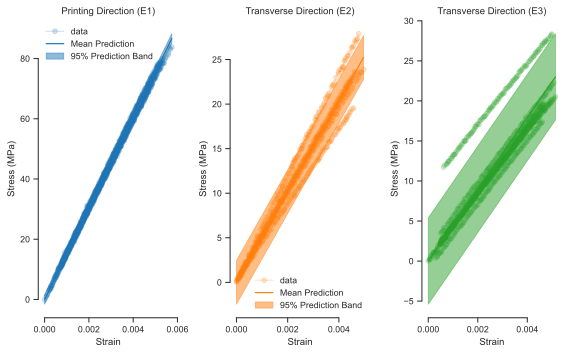

In [11]:
# Solution a - MLE approach: E is fixed, show uncertainty in stress predictions due to observation noise only

def find_prediction_bands(E_mle, sigma2, strain_grid):
    """Calculates the 95% prediction bands for stress given fixed E and observation noise.
    
    Arguments
    E_mle      -- The MLE of Young's modulus (MPa) 
    sigma2     -- The MLE of the observation noise variance (MPa^2)
    strain_grid-- The strain values to predict stress for

    Returns
    stress_mean -- The mean stress prediction (MPa)
    stress_lower-- The lower bound of the 95% prediction band (MPa)
    stress_upper-- The upper bound of the 95% prediction band (MPa)
    """
    # Mean prediction with fixed E
    stress_mean = E_mle * strain_grid
    
    # Prediction bands account for observation noise only (E is treated as known)
    stress_lower = stress_mean - 1.96 * np.sqrt(sigma2)
    stress_upper = stress_mean + 1.96 * np.sqrt(sigma2)
    
    return stress_mean, stress_lower, stress_upper

# Generate the strain grid for evaluating the mean and prediction bands
E1_xx = np.linspace(0, np.max(E1_strain), 100)
E2_xx = np.linspace(0, np.max(E2_strain), 100)
E3_xx = np.linspace(0, np.max(E3_strain), 100)

# Calculate the 95% prediction bands for each direction (MLE approach: fixed E + observation noise)
E1_mean, E1_lower, E1_upper = find_prediction_bands(E1_mle, E1_sigma2, E1_xx)
E2_mean, E2_lower, E2_upper = find_prediction_bands(E2_mle, E2_sigma2, E2_xx)
E3_mean, E3_lower, E3_upper = find_prediction_bands(E3_mle, E3_sigma2, E3_xx)

# Plotting the stress-strain curves with prediction bands
fig, axs = plt.subplots(1, 3, figsize=(8, 5))
# Plot E1
for i in range(E1_stress.shape[1]):
    if i == 0:
        axs[0].plot(E1_strain[:, i], E1_stress[:, i], 'o-', color=colors[0], alpha=0.2, label='data')
    else:
        axs[0].plot(E1_strain[:, i], E1_stress[:, i], 'o-', color=colors[0], alpha=0.2)
axs[0].plot(E1_xx, E1_mean, color=colors[0], label='Mean Prediction')
axs[0].fill_between(E1_xx, E1_lower, E1_upper, color=colors[0], alpha=0.5, label='95% Prediction Band')
axs[0].set_title('Printing Direction (E1)')
axs[0].set_xlabel('Strain')
axs[0].set_ylabel('Stress (MPa)')
axs[0].legend(frameon=False)

# Plot E2
for i in range(E2_stress.shape[1]):
    if i == 0:
        axs[1].plot(E2_strain[:, i], E2_stress[:, i], 'o-', color=colors[1], alpha=0.2, label='data')
    else:
        axs[1].plot(E2_strain[:, i], E2_stress[:, i], 'o-', color=colors[1], alpha=0.2)
axs[1].plot(E2_xx, E2_mean, color=colors[1], label='Mean Prediction')
axs[1].fill_between(E2_xx, E2_lower, E2_upper, color=colors[1], alpha=0.5, label='95% Prediction Band')
axs[1].set_title('Transverse Direction (E2)')
axs[1].set_xlabel('Strain')
axs[1].set_ylabel('Stress (MPa)')
axs[1].legend(frameon=False, loc='lower right')

# Plot E3
for i in range(E3_stress.shape[1]):
    if i == 0:
        axs[2].plot(E3_strain[:, i], E3_stress[:, i], 'o-', color=colors[2], alpha=0.2, label='data')
    else:
        axs[2].plot(E3_strain[:, i], E3_stress[:, i], 'o-', color=colors[2], alpha=0.2)
axs[2].plot(E3_xx, E3_mean, color=colors[2], label='Mean Prediction')
axs[2].fill_between(E3_xx, E3_lower, E3_upper, color=colors[2], alpha=0.5, label='95% Prediction Band')
axs[2].set_title('Transverse Direction (E3)')
axs[2].set_xlabel('Strain')
axs[2].set_ylabel('Stress (MPa)')
sns.despine(trim=True)
plt.tight_layout()
plt.show()

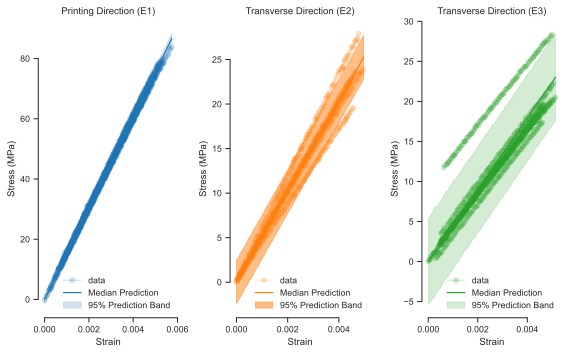

In [12]:
# Solution b - Monte Carlo approach (matches Solution A: fixed E + observation noise only)

# For verification: this should give nearly identical results to Solution A

def sample_model_mle(E_mle, sigma2, strain):
    """Sample stress predictions using MLE approach: fixed E + observation noise only.
    
    Arguments
    E_mle  -- The MLE of Young's modulus (MPa) - treated as fixed/known
    sigma2 -- The MLE of the noise variance (MPa^2)
    strain -- The strain data (mm/mm)
    
    Returns
    stress -- The sampled stress data (MPa)
    """
    # MLE approach: E is fixed (no parameter uncertainty), only observation noise
    stress = E_mle * strain + np.random.normal(0, np.sqrt(sigma2), strain.shape)
    return stress

# Create a grid of strain values for each direction
E1_xx = np.linspace(0, np.max(E1_strain), 100)
E2_xx = np.linspace(0, np.max(E2_strain), 100)
E3_xx = np.linspace(0, np.max(E3_strain), 100)

# Set up monte carlo sampling parameters
n_samples = 10000

# Create empty arrays to hold the model samples
E1_model_samples = np.empty((n_samples, len(E1_xx)))
E2_model_samples = np.empty((n_samples, len(E2_xx)))
E3_model_samples = np.empty((n_samples, len(E3_xx)))

# Sample the model for each direction (MLE approach: fixed E + observation noise)
for i in range(n_samples):
    E1_model_samples[i, :] = sample_model_mle(E1_mle, E1_sigma2, E1_xx)
    E2_model_samples[i, :] = sample_model_mle(E2_mle, E2_sigma2, E2_xx)
    E3_model_samples[i, :] = sample_model_mle(E3_mle, E3_sigma2, E3_xx)

# Find the median and 95% prediction bands for each direction (should match Solution A)
E1_median = np.median(E1_model_samples, axis=0)
E2_median = np.median(E2_model_samples, axis=0)
E3_median = np.median(E3_model_samples, axis=0)

E1_lower = np.percentile(E1_model_samples, 2.5, axis=0)
E2_lower = np.percentile(E2_model_samples, 2.5, axis=0)
E3_lower = np.percentile(E3_model_samples, 2.5, axis=0)

E1_upper = np.percentile(E1_model_samples, 97.5, axis=0)
E2_upper = np.percentile(E2_model_samples, 97.5, axis=0)
E3_upper = np.percentile(E3_model_samples, 97.5, axis=0)

# Plot the median and 95% prediction bands over the data
fig, axs = plt.subplots(1, 3, figsize=(8, 5))

# Plot E1
for i in range(E1_stress.shape[1]):
    if i == 0:
        axs[0].plot(E1_strain[:, i], E1_stress[:, i], 'o-', color=colors[0], alpha=0.2, label='data')
    else:
        axs[0].plot(E1_strain[:, i], E1_stress[:, i], 'o-', color=colors[0], alpha=0.2)
axs[0].plot(E1_xx, E1_median, color=colors[0], label='Median Prediction')
axs[0].fill_between(E1_xx, E1_lower, E1_upper, color=colors[0], alpha=0.2, label='95% Prediction Band')
axs[0].set_title('Printing Direction (E1)')
axs[0].set_xlabel('Strain')
axs[0].set_ylabel('Stress (MPa)')
axs[0].legend(frameon=False, loc='lower right')    

# Plot E2
for i in range(E2_stress.shape[1]):
    if i == 0:
        axs[1].plot(E2_strain[:, i], E2_stress[:, i], 'o-', color=colors[1], alpha=0.2, label='data')
    else:
        axs[1].plot(E2_strain[:, i], E2_stress[:, i], 'o-', color=colors[1], alpha=0.2)
axs[1].plot(E2_xx, E2_median, color=colors[1], label='Median Prediction')
axs[1].fill_between(E2_xx, E2_lower, E2_upper, color=colors[1], alpha=0.5, label='95% Prediction Band')
axs[1].set_title('Transverse Direction (E2)')
axs[1].set_xlabel('Strain')
axs[1].set_ylabel('Stress (MPa)')
axs[1].legend(frameon=False, loc='lower right')

# Plot E3
for i in range(E3_stress.shape[1]):
    if i == 0:
        axs[2].plot(E3_strain[:, i], E3_stress[:, i], 'o-', color=colors[2], alpha=0.2, label='data')
    else:
        axs[2].plot(E3_strain[:, i], E3_stress[:, i], 'o-', color=colors[2], alpha=0.2)
axs[2].plot(E3_xx, E3_median, color=colors[2], label='Median Prediction')
axs[2].fill_between(E3_xx, E3_lower, E3_upper, color=colors[2], alpha=0.2, label='95% Prediction Band')
axs[2].set_title('Transverse Direction (E3)')   
axs[2].set_xlabel('Strain')
axs[2].set_ylabel('Stress (MPa)')
axs[2].legend(frameon=False, loc='lower right')

sns.despine(trim=True)
plt.tight_layout()
plt.show()


## **Part 4: The Bayesian approach**

**Fundamental Shift in Thinking:** Unlike MLE (Part 3), the Bayesian approach treats Young's modulus E as a random variable with a probability distribution. Instead of finding a single "best" value, we quantify our uncertainty about E itself.

**Key Differences from MLE:**

| MLE Approach (Part 3) | Bayesian Approach (Parts 4-5) |
|----------------------|-------------------------------|
| E is a fixed unknown value | E is a random variable |
| Find single point estimate | Find full probability distribution |
| Uncertainty = measurement noise only | Uncertainty = parameter uncertainty (in this exercise) |
| "What's the best value of E?" | "What's the probability E is in any range?" |

**The Bayesian Recipe:**

The maximum likelihood provides a point estimate of our parameter, $E$, and places a distribution on the stress data. Observe the transverse direction, we can clearly see different slopes for different samples, meaning that $E$ can take on different values. We want to quantify the uncertainty in the elastic modulus with a probability distribution for $E$ given our data. We call this our **posterior distribution** - what we know about $E$ after we see our data:

$$
p(E \mid \text{data})
$$

**Three ingredients for Bayes' theorem:**

1. **Prior distribution** $p(E)$: What we know about $E$ before seeing data
2. **Likelihood** $p(\text{data} \mid E)$: How likely our data is for each value of $E$
3. **Posterior distribution** $p(E \mid \text{data})$: What we know about $E$ after seeing data

$$
p(E \mid \text{data}) = \frac{p(\text{data} \mid E) \times p(E)}{p(\text{data})}
$$

In words:
$$
\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}
$$

The evidence $p(\text{data})$ is just a normalizing constant ensuring the posterior integrates to 1.

**Interactive Example:**
Let me show you how prior and likelihood combine to form the posterior. Both prior and likelihood are Gaussian distributions, which conveniently results in a Gaussian posterior. Adjust the prior variance to see how it affects the posterior!

In [13]:
# Function to perform and plot the Bayesian update
def plot_bayesian_update(var0):
    mu0 = 0.0       # Prior mean (fixed)
    sigma_lik = 1.5 # Likelihood std (fixed)
    y_obs = 2.0     # Observed data (fixed)
    
    # Compute posterior parameters
    var_post = 1 / (1/var0 + 1/(sigma_lik**2))
    mu_post = var_post * (mu0/var0 + y_obs/(sigma_lik**2))
    
    # Create θ grid
    theta = np.linspace(mu0 - 4*np.sqrt(var0), mu0 + 4*np.sqrt(var0), 1000)
    
    # Compute densities
    prior_pdf     = stats.norm.pdf(theta, mu0, np.sqrt(var0))
    likelihood_pdf = stats.norm.pdf(theta, y_obs, sigma_lik)
    posterior_pdf = stats.norm.pdf(theta, mu_post, np.sqrt(var_post))
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(theta, prior_pdf, '--', color=colors[0], label=f'Prior: N({mu0}, {var0:.2f})')
    plt.plot(theta, likelihood_pdf, color=colors[3], label=f'Likelihood: N(obs={y_obs}, σ={sigma_lik})')
    plt.plot(theta, posterior_pdf, color=colors[4], label=f'Posterior: N({mu_post:.2f}, {var_post:.2f})')
    plt.xlabel('θ')
    plt.ylabel('Density')
    plt.title('Bayesian Update with Varying Prior Variance')
    plt.xlim(-5, 5)
    plt.ylim(0, 0.5)
    plt.legend(loc='upper left')
    sns.despine(trim=True)
    plt.show();

# Create an interactive slider for prior variance
widgets.interact(
    plot_bayesian_update,
    var0=widgets.FloatSlider(
        value=1.0,
        min=0.01,
        max=10.0,
        step=0.01,
        description='Prior Var'
    )
);

interactive(children=(FloatSlider(value=1.0, description='Prior Var', max=10.0, min=0.01, step=0.01), Output()…

As the prior variance increases, meaning the more uncertainty we have about the parameter before we see any data, the more we uncertainty we get in our posterior distribution, and the more that we trust the data to inform us about the parameter. But when the prior variance is very small, we have a strong belief about the parameter, and the posterior distribution is very close to the prior distribution. This means that we are not trusting the data to inform us about the parameter, and we are relying on our prior belief.

Unfortunately, not all posteriors are analytically available to use like the one above. Only certain combinations of priors and likelihoods yield analytical expressions for the posterior distribution, these combinations are often referred to as *conjugate priors*. Often times, when we do not have a conjugate prior, we need to use numerical methods to approxiimate the posterior distribution. 

**Question:**

+ Go to the [conjugate priors wikipedia page](https://en.wikipedia.org/wiki/Conjugate_prior#When_likelihood_function_is_a_continuous_distribution) and look at the table where the likelihood function is a continuous distribution. I demonstrated the first row for you, which is the Gaussian likelihood with a Gaussian prior. Pick another row, right down the mathematical expression for the "Posterior Hyperparameters"
+ Plot the prior, likelihood, and posterior distributions for the row you picked, if you want to make a slider to visualize changing a parameter, you can use the `ipywidgets` library as I did above, but you are free to plot a fixed parameter set. Use `scipy.stats` to compute the pdf from your posterior prarameters

*YOUR MATH HERE!*

In [14]:
# YOUR CODE HERE!

EXAMPLE SOLUTION:

$$
\alpha' = \alpha_0 + n
$$

$$
\beta' = \beta_0 + \sum_{i=1}^n x_i
$$

In [ ]:
# Example Solution - Gamma Prior and Exponential Likelihood for Gamma posterior

def plot_gamma_update(alpha0, beta0):
    # Fixed observation
    y_obs = 2.0

    # Posterior parameters
    alpha_post = alpha0 + 1
    beta_post = beta0 + y_obs

    # Grid for λ
    lam = np.linspace(0.01, 5, 1000)

    # Compute densities
    prior_pdf = stats.gamma.pdf(lam, a=alpha0, scale=1/beta0)
    likelihood = lam * np.exp(-lam * y_obs)
    posterior_pdf = stats.gamma.pdf(lam, a=alpha_post, scale=1/beta_post)

    # Plot
    plt.figure()
    plt.plot(lam, prior_pdf, '--', color=colors[0], label=f'Prior: Gamma(α={alpha0:.2f}, β={beta0:.2f})')
    plt.plot(lam, likelihood, color=colors[3], label='Likelihood')
    plt.plot(lam, posterior_pdf, color=colors[4], label=f'Posterior: Gamma(α={alpha_post:.2f}, β={beta_post:.2f})')
    plt.xlabel('λ')
    plt.ylabel('Density / Scaled Likelihood')
    plt.title('Bayesian Update: Gamma Prior & Exponential Likelihood')
    plt.xlim(0, 5)
    plt.ylim(0, 1)
    plt.legend(loc='upper right')
    sns.despine(trim=True)
    plt.show()

# Interactive sliders for α and β
widgets.interact(
    plot_gamma_update,
    alpha0=widgets.FloatSlider(value=5.0, min=0.1, max=10.0, step=0.1, description='α (shape)'),
    beta0=widgets.FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='β (rate)')
);

interactive(children=(FloatSlider(value=5.0, description='α (shape)', max=10.0, min=0.1), FloatSlider(value=2.…

## **Part 5: Applying Bayes' rule to find the modulus of elasticity**

Let's apply what we learned in Part 4 to our actual stress-strain measurements.

**Compare with Part 3:**
- **Part 3 (MLE):** Found E_mle = single point estimate, prediction bands = ± measurement noise only
- **Part 5 (Bayesian):** Will find p(E|data) = full distribution, credible bands = parameter uncertainty only

**Note:** We're separating different types of uncertainty to help you understand each source clearly.

**Setting up Bayes' rule for our problem:**

$$
p(E \mid \hat y, \epsilon) = \frac{p(\hat y \mid E, \epsilon) \times p(E)}{p(\hat y, \epsilon)}
$$

Where:
- $p(E)$ = **Prior**: What we think about E before seeing data
- $p(\hat y \mid E, \epsilon)$ = **Likelihood**: Same as Part 3 (how likely our data is for each E)
- $p(E \mid \hat y, \epsilon)$ = **Posterior**: What we think about E after seeing data

**Step 1: Choose a prior distribution**

We need to specify what we believe about E before seeing any data. For simplicity, we'll use a Gaussian prior:

$$
p(E) \sim \mathcal{N}(\mu_0, \sigma_0^2)$$

**Key insight:** The wider our prior (larger $\sigma_0^2$), the less confident we are about E beforehand, so the data will have a strong influence on our posterior.

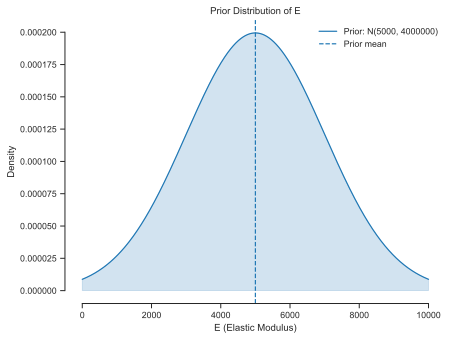

In [16]:
# Get a nice broad prior for E
mu0 = 5000.0         # prior mean
std0 = 2000.0    # prior std deviation
sigma2_0 = std0**2  # prior variance

E_grid = np.linspace(0, 10000, 2000)
prior_pdf = stats.norm.pdf(E_grid, loc=mu0, scale=std0)

plt.figure()
plt.plot(E_grid, prior_pdf, color=colors[0], label=f'Prior: N({mu0:.0f}, {std0**2:.0f})')
plt.fill_between(E_grid, prior_pdf, color=colors[0], alpha=0.2)
plt.axvline(mu0, ls='--', color=colors[0], label='Prior mean')
plt.xlabel('E (Elastic Modulus)')
plt.ylabel('Density')
plt.title('Prior Distribution of E')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

Now we will be using a Gaussian likelihood function, let's start by looking at it for one observation, which is a Gaussian distribution with mean $E\,\epsilon$ and variance a fixed variance $\sigma^2$.

$$
p(\hat y_i \mid \epsilon_i, E, \sigma^2) \sim \mathcal{N}(E\,\epsilon_i, \sigma^2)
$$

Number of data points: 695


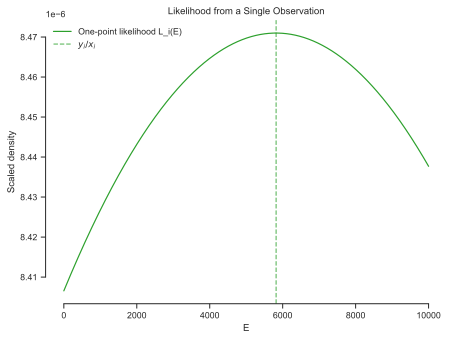

In [17]:
# Prepare data for E2
x = E2_strain.reshape(-1).astype(float)   # strain
y = E2_stress.reshape(-1).astype(float)   # stress
mask = np.isfinite(x) & np.isfinite(y) & (x != 0)
x = x[mask]; y = y[mask]
N = len(x)  # number of data points
print(f'Number of data points: {N}')

# Fixed variance
sigma2 = 1000.0

# Pick one point to illustrate
i = 100
mu_i = y[i] / x[i]
var_i = sigma2 / (x[i]**2)
pdf_i = stats.norm.pdf(E_grid, loc=mu_i, scale=np.sqrt(var_i))
# pdf_i = stats.norm.pdf(E_grid, loc=mu_i, scale=np.sqrt(sigma2))  # WRONG: uses observation noise, not parameter uncertainty

# Plot the one-point likelihood
plt.figure()
plt.plot(E_grid, pdf_i, color=colors[2], label=f'One-point likelihood L_i(E)')
plt.axvline(mu_i, ls='--', color=colors[2], alpha=0.7, label=r'$y_i/x_i$')
plt.xlabel('E')
plt.ylabel('Scaled density')
plt.title('Likelihood from a Single Observation')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.tight_layout()
plt.show()


Let's now take a look at the full likelihood function for all observations, which is the product of the individual likelihoods:

$$
p(\hat y \mid \epsilon, E, \sigma^2) = \prod_{i=1}^N p(\hat y_i \mid \epsilon_i, E, \sigma^2)
$$

For numerical convenience, we will take agan take the logarithm of the likelihood function, which is called the log-likelihood function:

$$
\log p(\hat y \mid \epsilon, E, \sigma^2) = \sum_{i=1}^N \log p(\hat y_i \mid \epsilon_i, E, \sigma^2)
$$ 

Simpliying to:

$$
\log p(\hat y \mid \epsilon, E, \sigma^2) = -\frac{1}{2 \sigma^2} \sum_{i=1}^N (\hat y_i - E\,\epsilon_i)^2 + \text{const}
$$

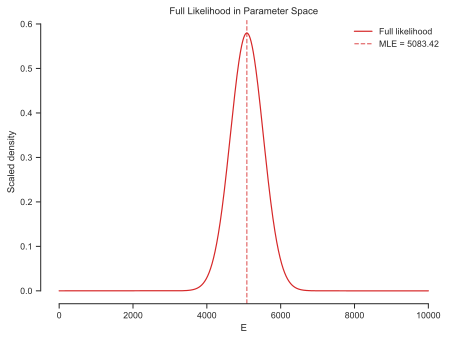

In [18]:
S_xx = np.sum(x**2)
S_xy = np.sum(x * y)

# MLE slope (OLS)
E_hat = S_xy / S_xx

def loglike(E, x, y, sigma2):
    return -0.5/sigma2 * np.sum((y - E*x)**2)

logL_vals = np.array([loglike(E, x, y, sigma2) for E in E_grid])
L_vals = np.exp(logL_vals) 

plt.figure()
plt.plot(E_grid, L_vals, color=colors[3], label='Full likelihood')
plt.axvline(E_hat, ls='--', color=colors[3], alpha=0.7, label=f'MLE = {E_hat:.2f}')
plt.xlabel('E')
plt.ylabel('Scaled density')
plt.title('Full Likelihood in Parameter Space')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

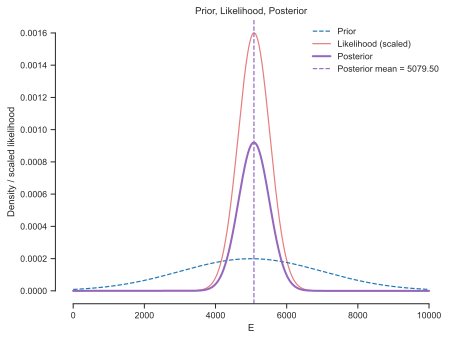

Posterior mean     μ_n = 5079.502
Posterior variance σ_n² = 187942.203


In [19]:
sigma_n_sq = 1.0 / (1.0 / sigma2_0 + S_xx / sigma2)
mu_n = sigma_n_sq * (mu0 / sigma2_0 + S_xy / sigma2)

post_pdf = stats.norm.pdf(E_grid, loc=mu_n, scale=np.sqrt(sigma_n_sq))
s_L_vals = L_vals * 3*np.max(post_pdf)  # scaled likelihood

plt.figure()
plt.plot(E_grid, prior_pdf, '--', color=colors[0], label='Prior')
plt.plot(E_grid, s_L_vals,     color=colors[3],  alpha=0.6, label='Likelihood (scaled)')
plt.plot(E_grid, post_pdf,   color=colors[4],  lw=2,      label='Posterior')
plt.axvline(mu_n, ls='--', color=colors[4], label=f'Posterior mean = {mu_n:.2f}')
plt.xlabel('E')
plt.ylabel('Density / scaled likelihood')
plt.title('Prior, Likelihood, Posterior')
plt.legend(frameon=False)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

print(f'Posterior mean     μ_n = {mu_n:.3f}')
print(f'Posterior variance σ_n² = {sigma_n_sq:.3f}')


### Key Comparison: MLE vs Bayesian Results

**Let's compare what we learned from each approach:**

**MLE Approach (Part 3):**
- **E estimate**: Single point value (e.g., E = 2847 MPa)
- **Uncertainty**: Only measurement noise in predictions
- **Philosophy**: "E is unknown but fixed, find the best estimate"
- **Prediction bands**: Narrow (just ± observation noise)

**Bayesian Approach (Part 5):**
- **E estimate**: Full probability distribution with mean and variance
- **Uncertainty**: Parameter uncertainty  
- **Philosophy**: "E is uncertain, quantify all our uncertainty"
- **Credible bands**: Wider (includes uncertainty about E itself)

**Which approach is "better"?**
- **MLE**: Simpler, gives definitive point estimates, faster computation
- **Bayesian**: More complete uncertainty quantification, incorporates prior knowledge, honest about what we don't know

**For engineering decisions**: Bayesian intervals give you a more complete picture of uncertainty, which is crucial for safety margins and risk assessment!


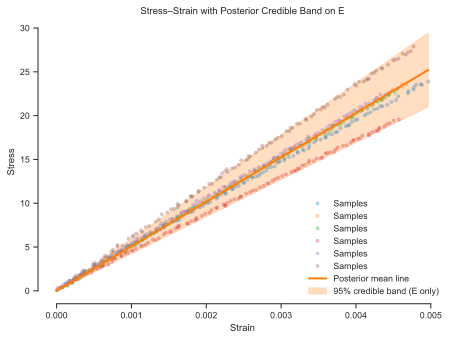

In [20]:
E_lo = mu_n - 1.96*np.sqrt(sigma_n_sq)
E_hi = mu_n + 1.96*np.sqrt(sigma_n_sq)

eps_grid = np.linspace(0, x.max(), 200)
stress_mean = mu_n * eps_grid
stress_lo   = E_lo * eps_grid
stress_hi   = E_hi * eps_grid

plt.figure()
plt.plot(E2_strain, E2_stress, 'o', ms=3, alpha=0.25, label='Samples')
plt.plot(eps_grid, stress_mean, color=colors[1], lw=2, label='Posterior mean line')
plt.fill_between(eps_grid, stress_lo, stress_hi, color=colors[1], alpha=0.25,
                 label='95% credible band (E only)')
plt.xlabel('Strain')
plt.ylabel('Stress')
plt.title('Stress–Strain with Posterior Credible Band on E')
plt.legend(frameon=False, loc='lower right')
sns.despine(trim=True)
plt.tight_layout()
plt.show()
